# Jupyer Notebook for Controlling  Stepper Motors Linear rail with an Arduino with Integrated UV-Vis measurements using a HR2000+ Spectrometer


 Version 2.1 JULY 2023

YuCheng, Imperial College London (Adapted from Niall M)

Controlling 1 stepper motors with integrated measurements

# Imports for seabreeze (spectrometer), serial (motor) and standard libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time
from time import perf_counter
import serial
import serial.tools.list_ports
from serial import Serial
from IPython import display
from scipy.optimize import curve_fit 
from scipy import interpolate
from pylab import *
from math import *
from datetime import datetime
import seabreeze.spectrometers as sb
#import seabreeze.pyseabreeze as psb
import seabreeze.cseabreeze as csb
### os
import os
###import custom functions / class
import SpectrometerMultiplexerFunctions as SMF
### astropy signal processing
from astropy.convolution import convolve, Box1DKernel
from sklearn.cluster import KMeans
from pathlib import Path

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


# Make an object called spec from the Spectrometer Class

In [2]:
#plot the data
def plotting_spectra (wavelengths, intensities, smoothbool, smoothfactor, color,xlim1,xlim2,ylim1,ylim2):
    fig,ax = plt.subplots()
    if smoothbool == True:
        intensities = convolve(intensities, Box1DKernel(smoothfactor))
    ax.plot(wavelengths, intensities, color = color)
    plt.ylabel('Intensity (a.u)')
    plt.xlabel('Wavelength (nm)')
    ax.yaxis.grid(True)
    ax.tick_params(axis = 'x',rotation=45)
    ax.xaxis.tick_bottom()
    if xlim2 >1:
        plt.xlim(xlim1,xlim2)
    if ylim2 >1:
        plt.ylim(ylim1,ylim2)
    plt.show()
    return wavelengths,intensities
    

In [3]:
## Normalise and reduce data
def normalizeAndReduce(wavelength, intensity, lower_bin, upper_bin):
    count1 = 0
    count2 = 0
    sumwave1 = 0
    sumwave2 = 0
    
    # enumerate data - lower bin first 
    for i, val in enumerate(wavelength):
        if val >= lower_bin[0] and val <= lower_bin[1]:
            sumwave1 +=  intensity[i]
            count1 += 1
    # enumerate data - upper bin second 
    if upper_bin == (0,0):
        return (sumwave1 / count1)
    else: 
        for i, val in enumerate(wavelength):
            if val >= upper_bin[0] and val <= upper_bin[1]:
                sumwave2 = sumwave2 + intensity[i]
                count2 += 1
        return ((sumwave1 / count1) / (sumwave2 / count2)) * 100
    


In [4]:
def monitorfunction(position,spec, totaltime,recordstep,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
    initialtime = time.perf_counter() ## initial time at start
    stoploop = True   # start the while loop
    totaltime = totaltime  ## time you want the while loop to run in seconds
    spec.integration_time_micros(integration) ## set integration time

    while stoploop == True:
        wavelengths, intensities = spec.spectrum(correct_dark_counts=darkcounts, correct_nonlinearity=nonlinearity)
        
        absmonitor1 = normalizeAndReduce(wavelengths, intensities, lower_bin=(UVbin1, UVbin2), 
                                           upper_bin=(Refbin1,Refbin2))
        absmonitor2 = normalizeAndReduce(wavelengths, intensities, lower_bin=(Visbin1, Visbin2), 
                                           upper_bin=(Refbin1,Refbin2))

        t = time.perf_counter()
        elapsed_time = t - initialtime
        print(position,'monitoring UV abs =',int(absmonitor1),'Vis abs =',int(absmonitor2), 'shottime =',int(elapsed_time),'s')
        data_end = plotting_spectra(wavelengths, intensities, smoothbool, smoothfactor, color,xlim1,xlim2,ylim1,ylim2)

        if elapsed_time > totaltime:  ## check if the amount of time has elapased and turn off the while loop, ending the process
            stoploop = False
            return data_end,absmonitor1,absmonitor2 #return the data of the last fig
        else:
            display.clear_output(wait=True)
            time.sleep(recordstep)#set record time gap

# Live Viewing Spectra

In [5]:
Spectrometer = sb.Spectrometer.from_serial_number('HR+C3148')
#Spectrometer2 = sb.Spectrometer.from_first_available()
#sb.list_devices()
SMF.SpectrometerInformation (Spectrometer)

The model of the spectrometer: HR2000PLUS
The serial number of the spectrometer: HR+C3148
The number of pixels of the spectrometer: 2048
The min and max integrationt ime of the spectrometer: (1000, 655350000) ms
The maximum intensity of the spectrometer is: 16383.0
The features of the spectrometer: {'raw_usb_bus_access': [<SeaBreezeRawUSBBusAccessFeature:HR2000PLUS:HR+C3148 id=720896>], 'spectrometer': [<SeaBreezeSpectrometerFeature:HR2000PLUS:HR+C3148 id=131072>], 'pixel_binning': [], 'thermo_electric': [], 'irrad_cal': [<SeaBreezeIrradCalFeature:HR2000PLUS:HR+C3148 id=262144>], 'ethernet_configuration': [], 'multicast': [], 'ipv4': [], 'dhcp_server': [], 'network_configuration': [], 'wifi_configuration': [], 'gpio': [], 'eeprom': [<SeaBreezeEEPROMFeature:HR2000PLUS:HR+C3148 id=327680>], 'light_source': [], 'strobe_lamp': [<SeaBreezeStrobeLampFeature:HR2000PLUS:HR+C3148 id=393216>], 'continuous_strobe': [<SeaBreezeContinuousStrobeFeature:HR2000PLUS:HR+C3148 id=786432>], 'shutter': [],

# Motor Class - will call from .py File 



In [6]:
# Version 1.1 February 2023
# Niall McIntyre Imperial College London (Adapted from Nick Brooks)
# Contolling two stepper motors via an Arduino

class MotorControl:
    '''
    Class used to allow serial communication between computer and 2 stepper motors via an Arduino
    '''
    def __init__(self,motor_number):
        '''
        Initalise the motor. All other variables controlled in .ino file
        '''
        self.motor_number = motor_number
        
        if self.motor_number != 1 and self.motor_number !=2:
              raise Exception("Incorrect Motor Number - only takes integer values 1 or 2")


    def setUpSerialPort(self):
        '''
        Sets up the serial connection between the computer (controlled via Jupyter) and the Arduino microcontroller
        '''
        global ser #setting up ser as a global variable
        serialport = 0
        setupstring = ''
        ports = serial.tools.list_ports.comports() #computer collecting the ports
        for p in ports: #loop through ports
            print(p) #print ports
            if 'Arduino' in str(p):# new laptop can not get arduino strings so USB is used here
                serialport = str(p.device) #just takes the port - i.e. COM3-=
        if serialport == 0:
            raise Exception("no Arduino connected")
        else:
            ser = serial.Serial(serialport, baudrate=115200, timeout=1) #then updates ser to take into account serial port
        print ('Connected to '+serialport+'\n')
        for i in range(3):
            b = ser.readline() #used if know input terminated with EOL characteres
            readstring = b.decode("utf-8")
            setupstring+=readstring
        print(setupstring)
    
    
    def setMotorDirection(self, direction):
        '''
        Setting the direction the stepper motor will turn. 1 = clockwise,  0 = anticlockwise
        '''
        global ser
        
        if self.motor_number == 1:
            writestring = '<M'+str(direction)+'>'
            bytestowrite = writestring.encode() #encodes the string to UTF-8
            ser.write(bytestowrite) # sending the data
            b = ser.readline()
            readstring = b.decode("utf-8")
            print(f"Motor {self.motor_number} turning {readstring}")
        elif self.motor_number == 2:
            writestring = '<N'+str(direction)+'>'
            bytestowrite = writestring.encode() #encodes the string to UTF-8
            ser.write(bytestowrite) # sending the data
            b = ser.readline()
            readstring = b.decode("utf-8")
            print(f"Motor {self.motor_number} turning {readstring}")
    
    def setDistance(self, dist):
        '''
        Sets the distance the motor will move. 
        '''
        global ser
        global ser
        if dist ==0:
            return
            
        elif dist<0: # negative come to left
            self.setMotorDirection(1)
        elif dist>0: # positive come to right
            self.setMotorDirection(0)
        dist = abs(dist)  
        if self.motor_number == 1:
            writestring = '<L'+str(dist)+'>'
            bytestowrite = writestring.encode() #encodes the string to UTF-8
            ser.write(bytestowrite) # sending the data
            b = ser.readline()
            readstring = b.decode("utf-8")
            print(f'Motor {self.motor_number} distance set to {dist} unit')
            
        if self.motor_number == 2:
            writestring = '<P'+str(dist)+'>'
            bytestowrite = writestring.encode() #encodes the string to UTF-8
            ser.write(bytestowrite) # sending the data
            b = ser.readline()
            readstring = b.decode("utf-8")
            print(f'Motor {self.motor_number} distance set to {readstring} unit')
            
    def stopmotor(self,readtime):
        '''
        stop the motor for reading
        '''
        global ser
        if self.motor_number == 1:
            writestring = '<S'+str(readtime)+'>'
            bytestowrite = writestring.encode() #encodes the string to UTF-8
            ser.write(bytestowrite) # sending the data
            b = ser.readline()
            readstring = b.decode("utf-8")
            print(f'Motor {self.motor_number} stop for {readtime/1000} s')
        if self.motor_number == 2:
            writestring = '<S'+str(readtime)+'>'
            bytestowrite = writestring.encode() #encodes the string to UTF-8
            ser.write(bytestowrite) # sending the data
            b = ser.readline()
            readstring = b.decode("utf-8")
            print(f"Motor {self.motor_number} has moved {readstring} unit")
    def ReadOutput(self):
        '''report the motor has stopped'''
        global ser
        b = ser.readline()
        readstring = b.decode("utf-8")
        return readstring

In [7]:
ports = serial.tools.list_ports.comports()

for p in ports: #loop through ports
            print(p) #print ports

COM3 - Intel(R) Active Management Technology - SOL (COM3)
COM4 - Arduino Uno (COM4)


# Connect Motor 

In [8]:
motor1 = MotorControl(1)
#motor2 = MotorControl(2)

In [9]:
motor1.setUpSerialPort()

COM3 - Intel(R) Active Management Technology - SOL (COM3)
COM4 - Arduino Uno (COM4)
Connected to COM4

We are Connected


## MOVEMENT TEST

In [11]:
# 0: away from motor 1: towards motor

motor1.setDistance(-500)

Motor 1 turning InPosition

Motor 1 distance set to 500 unit


# moving motor and monitoring spectrum

In [12]:
def MoveAndMonitor(position,distance,spec,recordtimelength,recordstep,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
    Moving = True 
    if distance==0:
        Moving = False
        Monitor_data_end,UV_abs_end,Vis_abs_end = monitorfunction(position,spec,recordtimelength,recordstep,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2)
        return Monitor_data_end,UV_abs_end,Vis_abs_end
    else:
        motor1.setDistance(distance)
        while Moving == True:
            a = motor1.ReadOutput()
            #print(a)
            if 'InPosition' in a: #Feedbacks from auduino indicating a stop
                time.sleep(2)#extend wait time to stop shaking
                Moving = False
                Monitor_data_end,UV_abs_end,Vis_abs_end = monitorfunction(position,spec,recordtimelength,recordstep,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2)
                return Monitor_data_end,UV_abs_end,Vis_abs_end
            else:
                print(a)
                display.clear_output(wait=True)

## locate the first alignment point mannully

In [94]:
#check the spectrum of the frist alignment point 
#the UV region should appear on the spectrum, otherwise tilt/lift the chip slightly, optimal:~500
Monitor_1 = monitorfunction('Alignment point 1',Spectrometer,600,0.9,200000,True,10,True,True,'blue',0,0,0,0,250,290,600,650,0,0)

KeyboardInterrupt: 

## locate the second alignment point by code

In [163]:
# move to the second alignment point by code: 50mm equals to 10000 distance
# 0&1 is used for direction
# go to point 1
ax = MoveAndMonitor('Alignment point 1',-500,Spectrometer,5,0.9,150000,True,10,True,True,'blue',0,0,0,0,250,290,600,650,0,0)

#!!!!!go back to point 0 to start scan
    #ax = MoveAndMonitor('Alignment point 0',1,12000,Spectrometer,5,0.9,200000,True,10,True,True,'blue',0,0,0,0,240,290,600,650,800,850)

KeyboardInterrupt: 

## Scan droplet wells

In [35]:
def linearscan(microstep,welldistance,wellnumtoscan,scandirection):
    '''
    for calibration of xinterval and yinterval
    microstep: estimated stpes for 1mm: 200 step
    welldistance: designed interval between wells in mm: 10mm
    wellnumtoscan: at least cover 2 well
    start from and well, usually alignment hole
    scandirection:'+' or '-', + right - left 
    rememeber to move the detecter slightly out of well before scan
    '''
    scanlength = int(welldistance*(wellnumtoscan+0.5)*microstep+1)
    coordinates1 = np.arange(scanlength).astype(int)
    coordinates2 = np.zeros(scanlength).astype(int)
    if scandirection == '+':
        coordinates1 = coordinates1
    elif scandirection == '-':
        coordinates1 = coordinates1*-1
    LinearScanpoints = np.column_stack((coordinates1,coordinates2 ))
    return LinearScanpoints 

In [12]:
scanpoints= linearscan(microstep=50,welldistance=10,wellnumtoscan=6,scandirection='+')
scanpoints

array([[   0,    0],
       [   1,    0],
       [   2,    0],
       ...,
       [3248,    0],
       [3249,    0],
       [3250,    0]])

In [13]:
class ScanAndprofile():
    def __init__(self,scanpoints,spec,recordtimelength,recordstep,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
        self.data_list= []
        self.scanpoints=scanpoints
        for i,scanpoint in enumerate(scanpoints): 
            if i ==0:
                distance = 0
            else:
                distance = (scanpoints[i]-scanpoints[i-1])[0]
            data = MoveAndMonitor(scanpoint,distance,spec,recordtimelength,recordstep,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2)
            self.data_list.append({'Position': scanpoint, #create 3 data lists
                             'UVabs':data[1]})

        self.df = pd.DataFrame(self.data_list)   
    def saveScandata(self,savepath,filename):
        os.makedirs(savepath, exist_ok=True)
        self.df.to_csv(savepath,filename,index=True)


[3250    0] monitoring UV abs = 3 Vis abs = 1033 shottime = 0 s


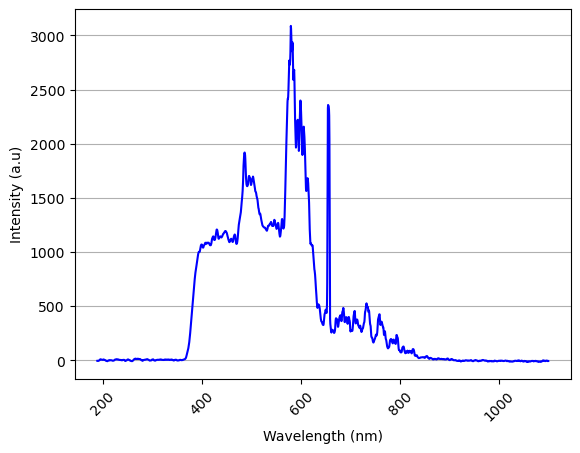

In [14]:
# set the recordlength for each step as 0.25, stepsleep as 0.1 and integration time as 100000ms to save time
Scan1 = ScanAndprofile(scanpoints,Spectrometer,0.25,0.1,100000,True,10,True,True,'blue',0,0,0,0,240,290,600,650,0,0)

In [27]:
Scan1.df

,Position,UVabs
0,"[0, 0]",-2.247954
1,"[1, 0]",5.522315
2,"[2, 0]",5.500220
3,"[3, 0]",4.509339
4,"[4, 0]",2.992297
...,...,...
3246,"[3246, 0]",3.483855
3247,"[3247, 0]",0.760915
3248,"[3248, 0]",5.176576
3249,"[3249, 0]",-0.486612


In [41]:
def saveScandata(df,savepath,scanname):
    x=np.array([df['Position'][i][0] for i in range (len(Scan1.df['Position']))]) 
    y=np.array([df['Position'][i][1] for i in range (len(Scan1.df['Position']))]) 
    z=np.array(df['UVabs'][:])  
    scandata = np.vstack((x,y,z))
    dirname = os.path.join(savepath,scanname)
    Path(dirname).mkdir(parents=True, exist_ok=True)
    file = f"{scanname}_{datetime.now().strftime('%H:%M:%S')}.npy".replace(":","_") ### generates a string with the current time used as a unique embedding
    filename = os.path.join(dirname,file)
    np.save(filename, scandata)
    return filename


In [42]:
saveScandata(df=Scan1.df,savepath='C:\data\Linear Rail Steroids',scanname='Calibration1')

'C:\\data\\Linear Rail Steroids\\Calibration1\\Calibration1_19_56_31.npy'

In [66]:
def wellcenterslocation(datapath,optical_clusters,point_nums):
    
    data = np.load(datapath)
    x=np.array(data)[0] 
    y=np.array(data)[1]
    z=np.array(data)[2] 
    
    data = np.column_stack((x, y,z))
    z = z.reshape(-1,1)
    # Initialize and fit a KMeans clustering model with 2 clusters
    #separate UV-transparent part and non-transparent part
    kmeans = KMeans(n_clusters=optical_clusters)
    kmeans.fit(z)

    # Get the cluster labels
    optical_labels = kmeans.labels_
    cluster_points = []
    cluster_Zaverages = []
    optical_centers = kmeans.cluster_centers_
    print("optical_centers:", optical_centers)
    # Separate data points into two clusters based on the cluster labels
    fig = plt.figure()
    for i in range(optical_clusters):
        cluster = data[optical_labels == i]
        cluster_points.append(cluster)
        plt.scatter(cluster[:,0],cluster[:,1],c=cluster[:,2],cmap='viridis', s=100)
        cluster_Zaverage = mean (cluster[:,2])
        cluster_Zaverages.append(cluster_Zaverage)
        plt.scatter(optical_centers[i], 0, c='b',marker = 'x', s=100)
    plt.colorbar(label='z')  # Add colorbar to show z values
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('2-D Scatter Plot with z')
    plt.grid(True)
    plt.show()
    # get the data for wells 
    # Get the index of the largest element
    welldata_label = cluster_Zaverages.index(max(cluster_Zaverages))
    
    welldata = data[optical_labels == welldata_label]
    print( optical_labels)
    # locate the centers of two droplet positions
    wellx = welldata[:,0]
    welly = welldata[:,1]
    # Assuming x, y are arrays containing the x and y coordinates of your data points

    # Combine x and y coordinates into a single array
    well_coordinates = np.column_stack((wellx, welly))
    #print(data)
    # Initialize and fit a KMeans clustering model with 2 clusters
    kmeans = KMeans(n_clusters=point_nums)
    kmeans.fit(well_coordinates)

    # Get the cluster labels
    welllabels = kmeans.labels_

    # Get the cluster centers
    point_centers = kmeans.cluster_centers_

    # Print or use the cluster centers as needed
    print("point_centers:", point_centers)
    plt.scatter(wellx, welly, c='r', s=100) 
    for i in range(point_nums):
        plt.scatter(point_centers[i,0], point_centers[i,1], c='b',marker = 'x', s=100) 
    #plt.xlim(-2,2)
    #plt.ylim(-2,2)
    return optical_centers, point_centers
def intervalcalibration(centers):
    # Sort the data points based on x-coordinate
    sorted_centers_indices = np.argsort(centers[:, 0]) 
    sorted_centers = centers[sorted_centers_indices]
    #print(sorted_centers)
    intervals = [sorted_centers[i+1]-sorted_centers[i] for i in range(len(sorted_centers)-1)]
    #print(intervals )
    calibrated_interval_instep = np.mean(intervals,axis=0)
    #print(calibrated_interval_instep)
    return intervals,calibrated_interval_instep

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


optical_centers: [[ 11.11125885]
 [131.90810111]]


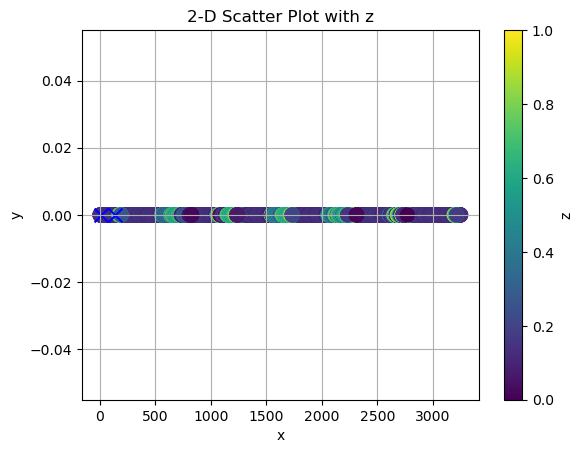

[0 0 0 ... 0 0 0]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


point_centers: [[2697.74489796    0.        ]
 [ 733.96385542    0.        ]
 [1641.5           0.        ]
 [2194.67816092    0.        ]
 [1164.86577181    0.        ]
 [ 179.5           0.        ]
 [3203.            0.        ]]


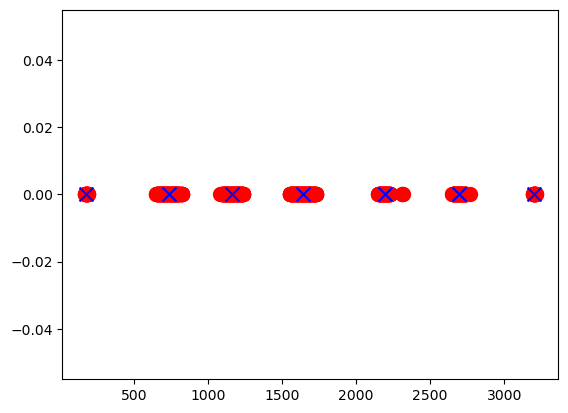

In [67]:
Scan1centers = wellcenterslocation(datapath=r'C:\\data\\Linear Rail Steroids\\Calibration1\\Calibration1_19_56_31.npy',optical_clusters=2,point_nums=7)

In [68]:
intervalcalibration(Scan1centers[1])

([array([554.46385542,   0.        ]),
  array([430.90191639,   0.        ]),
  array([476.63422819,   0.        ]),
  array([553.17816092,   0.        ]),
  array([503.06673704,   0.        ]),
  array([505.25510204,   0.        ])],
 array([503.91666667,   0.        ]))

# save data

In [13]:
def SpectroSavingAndMonitoring (foldername,position,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2, base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
    '''
    foldername = where this batch of data will be saved
    position = position of the well recording now
    spec = spectrometer object from seabreeze
    start_time = timepoint when measurement loop start
    OnceRecordLength = int / timewinbdow for once record
    integration = int / time to integrate for each spectra in micro seconds
    smoothbool = Bool whether to smoothen spectra or not 
    smoothfactor = int / width of box filter (x axis) --> 20 = high value
    darkcounts  = Bool - Whether to add darkcounts per spectra
    nonlinearity = Bool - whether to correct nonlinearity per spectra
    color = str / color of spectra
    x/ylim1/2 = int / stndrd mpl lims
    base_path = string containing the directory that contains the experiments directory'''
    
    ### ---- Initialise the function variables
    count = 0
    initialtime = time.perf_counter() ## initial time at start
    stoploop = True   # start the while loop
    #totaltime = OnceRecordLength  ## time you want the while loop to run in seconds
    spec.integration_time_micros(integration) ## set integration time
    wavelengths, intensities = spec.spectrum(correct_dark_counts=darkcounts, correct_nonlinearity=nonlinearity)
    spectra = np.vstack((wavelengths, intensities))
    abs1 = normalizeAndReduce(wavelengths, intensities, lower_bin=(UVbin1, UVbin2), 
                                           upper_bin=(Refbin1,Refbin2))
    abs2 = normalizeAndReduce(wavelengths, intensities, lower_bin=(Visbin1, Visbin2), 
                                           upper_bin=(Refbin1,Refbin2))
        ### check the time and then compare this to time to run for
    t = time.perf_counter()
    elapsed_time = t - initialtime
    recorded_time = t - start_time
    print(position,'saving UVabs =',int(abs1),'saving Visabs =',int(abs2),'at ',int(recorded_time),'s, Shottime =',int(elapsed_time),'s')
        ### --- Initialise directories for each position 

    data_end = plotting_spectra(wavelengths, intensities, smoothbool, smoothfactor, color,xlim1,xlim2,ylim1,ylim2)
         ###save to folder x 
    if foldername != 'NO save':
        dirname = os.path.join(base_path, foldername,position)
        Path(dirname).mkdir(parents=True, exist_ok=True)
        file = f"{foldername}_{position}_{datetime.now().strftime('%H:%M:%S')}.npy".replace(":","_") ### generates a string with the current time used as a unique embedding
        filename = os.path.join(dirname,file)
        np.save(filename, spectra)
    return data_end, abs1,abs2
      

In [14]:
def MoveAndSave(foldername,position,distance,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2, base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
    Moving = True
    motor1.setDistance(distance)
    
    n = 0 #position counter
    while Moving == True:
        a = motor1.ReadOutput()
        print(a)
        if 'InPosition' in a:# motor stopped
            Moving = False
            time.sleep(1.5)#extend wait time to stop shaking
            save_data_end,save_abs1_end,save_abs2_end = SpectroSavingAndMonitoring (foldername,position,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2, base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2)
            display.clear_output(wait=True)
            time.sleep(1.1)# wait before moving again let the data collection of spectrum finish !!! the record time length must be smaller tham the sleep time here 
            return save_data_end,save_abs1_end,save_abs2_end
        else:
            print('Moving')
            display.clear_output(wait=True)

In [15]:
def MultipleSave(foldername,direction,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
    start_time
    data_list= []

    #Distance_list1=[10.346*50,10*50,10*50,10*50,10*50,10.346*50] #stacked chip
    Distance_list1=[500,500,500,500,500,537]
    #Distance_list2=[-10.346*50,-10*50,-10*50,-10*50,-10*50,-10.346*50]
    Distance_list2=[-500,-500,-500,-500,-500,-537]

    Position_list1 = [1,3,5,7,9,11]
    #Position_list1 = [1,2,3,4,5,6]
    Position_list2 = [10,8,6,4,2,0]
    #Position_list2 = [5,4,3,2,1,0]
    
 
    if direction == 0:
        TruePosition_list = Position_list1   
        TrueDistance_list = Distance_list1
    else:
        TruePosition_list = Position_list2
        TrueDistance_list = Distance_list2
    for i,distance in zip(TruePosition_list,TrueDistance_list): 
        position = f'position{i}'
        data = MoveAndSave(foldername,position,distance,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2)
        data_list.append({'Position': position, 
                          'data':data[0],
                         'UVabs':data[1],
                         'Visabs':data[2]
                         })
        
        
    df = pd.DataFrame(data_list)   
        
            
  # 2*5 sub plots          
    '''
    num_rows = 5
    num_cols = 2
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 18))  # Adjust figsize as needed

    if direction == 1:
        reversed_axes = reversed(axes.flatten())
    else:
        reversed_axes = axes.flatten()

    for t, ax in enumerate(reversed_axes):
        data_x, data_y = df['data'][t]
        position = df['Position'][t]
        uv_abs = int(df['UVabs'][t])
        vis_abs = int(df['Visabs'][t])
    
        ax.plot(data_x, data_y)
        ax.set_title(f' {position}\nUVabs = {uv_abs}, Visabs = {vis_abs}')
        ax.set_xlabel('X-axis label')  # Set appropriate labels
        ax.set_ylabel('Y-axis label')
        ax.grid(True)  # Add grid for better readability

    plt.tight_layout()  # Adjust subplot spacing automatically
    plt.show()'''

In [16]:
def MultipleSaveLoop(totalrecordtime,spec,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2):
    # 240 s a loop
    LoopCount =0
    Foldername = input('Foldername')
    start_time = time.perf_counter() ## initial time at start
    stoploop = True   # start the while loop
    totalrecordtime=totalrecordtime ## time you want the while loop to run in seconds
    while stoploop == True:
        
        MultipleSave(Foldername,0,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2)
        #time.sleep(0.5)
        MultipleSave(Foldername,1,spec,start_time,integration,smoothbool, smoothfactor, darkcounts,nonlinearity, color,xlim1,xlim2, ylim1,ylim2,base_path,UVbin1,UVbin2,Visbin1,Visbin2,Refbin1,Refbin2) 
        #time.sleep(0.5)
        LoopCount +=1
        t = time.perf_counter()
        Recorded_time = t - start_time
        if Recorded_time > totalrecordtime:  ## check if the amount of time has elapased and turn off the while loop, ending the process
            stoploop = False
            return LoopCount


In [23]:
#new light source: 160000ms
# old light source 900000vms   
Monitor_1 = monitorfunction('Alignment point 1',Spectrometer,600,0.9,150000,True,10,True,True,'blue',0,0,0,0,250,290,600,650,0,0)

KeyboardInterrupt: 

# New Laptop

In [24]:
MultipleSaveLoop(3600,Spectrometer,150000,True,10,True,True,'blue',0,0,0,0,r'C:\data\YC\2025',250,290,600,650,0,0)

88

In [ ]:
ax = MoveAndMonitor('Alignment point 0',0,12020,Spectrometer,5,0.9,100000,True,10,True,True,'blue',0,0,0,0,240,290,600,650,0,0)